# 가설 N: 부양가족(Dependents): 홍지윤
* 부양가족이 있는 고객은 안정적인 보장을 원하므로, 1인 가구보다 이탈률이 낮을 것이다.
* 특히 가족 전체를 보장하는 **Home(화재)** 이나 **Health** 보험의 이탈률이 1인 가구보다 현저히 낮을 것이다.

In [13]:
# import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import load_data


In [3]:
# 전체 재실행 대비 주석처리
# %pip install pyxlsb
# %pip install xlsxwriter
# %pip uninstall streamlit-aggrid -y
# %pip install streamlit-aggrid==0.3.3

In [4]:
# # from pyxlsb import open_workbook as open_xlsb
# from st_aggrid import AgGrid
#
# grid_return = AgGrid(load_data())

## 데이터 수집

In [5]:
# 1. 데이터 로드
df = load_data()
df

,customer_id,as_of_date,region_name,age,age_band,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,...,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_type,churn_probability_true
0,1,2025-12-31,Manawatu-Whanganui,24,18-24,Married,128,1,4,Auto,...,7,1616,0,0,0,0,0,0,No churn,0.048626
1,2,2025-12-31,Auckland,70,65-74,Married,76,1,3,Auto,...,15,1760,1,0,0,0,0,0,No churn,0.067888
2,3,2025-12-31,Bay of Plenty,62,55-64,Married,129,0,1,Auto,...,24,1581,1,0,0,0,0,0,No churn,0.223765
3,4,2025-12-31,Bay of Plenty,47,45-54,Single,104,0,1,Auto,...,17,1688,1,0,0,0,0,0,No churn,0.602455
4,5,2025-12-31,Bay of Plenty,47,45-54,Married,22,1,3,Life,...,24,1592,1,0,0,0,0,0,No churn,0.050723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2025-12-31,Auckland,55,55-64,Single,25,0,1,Life,...,14,1379,2,0,0,0,0,0,No churn,0.260704
49996,49997,2025-12-31,Wellington,85,75+,Married,89,0,1,Health,...,26,741,0,0,0,0,0,1,Other,0.584094
49997,49998,2025-12-31,Auckland,28,25-34,Single,82,0,1,Home,...,26,320,5,0,0,0,0,0,No churn,0.179628
49998,49999,2025-12-31,Auckland,39,35-44,Single,55,0,1,Home,...,24,508,4,0,0,0,0,0,No churn,0.210082


In [6]:
df.head()

df.loc[:, 'is_churn'] = df['churn_flag']

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  str    
 2   region_name                  50000 non-null  str    
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  str    
 5   marital_status               50000 non-null  str    
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  str    
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_pct         

In [7]:
# 2. 전체 이탈률 비교 (Married vs Single)
overall_churn = df.groupby('marital_status')['is_churn'].agg(
    churn_num='sum',
    total_num='count',
    rate='mean'
).reset_index()
overall_churn

,marital_status,churn_num,total_num,rate
0,Married,8298,27643,0.300184
1,Single,6785,22357,0.303484


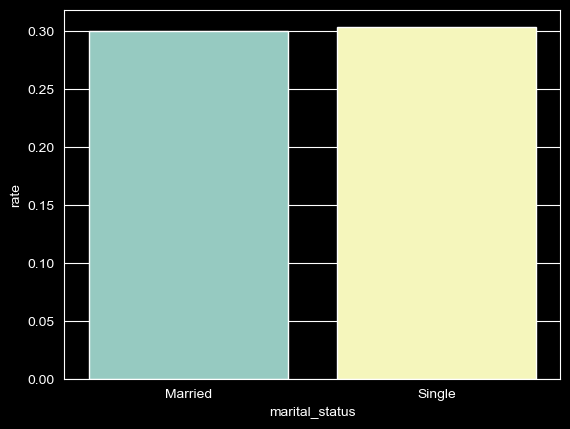

In [8]:
sns.barplot(data=overall_churn, x='marital_status', y='rate', hue='marital_status')
plt.show()

### 결론1: 결혼 유무는 이탈률에 유의미한 영향을 미치지 않는 것으로 확인됨.

### 가설1-2. 특정 상품군, 예를 들어, 건강이나 생명보험은 결혼 유무와 상관이 있을 것이다.

In [9]:
# 3. 상품군별 이탈률 비교
policy_churn = df.groupby(['policy_type', 'marital_status'])['is_churn'].agg(
    churn_num='sum',
    total_num='count',
    rate='mean'
).reset_index()
policy_churn

,policy_type,marital_status,churn_num,total_num,rate
0,Auto,Married,2660,8835,0.301075
1,Auto,Single,2253,7264,0.310160
2,Health,Married,2003,6666,0.300480
3,Health,Single,1633,5221,0.312775
4,Home,Married,1999,6659,0.300195
5,Home,Single,1556,5319,0.292536
6,Life,Married,1151,3862,0.298032
7,Life,Single,948,3219,0.294501
8,Travel,Married,485,1621,0.299198
9,Travel,Single,395,1334,0.296102


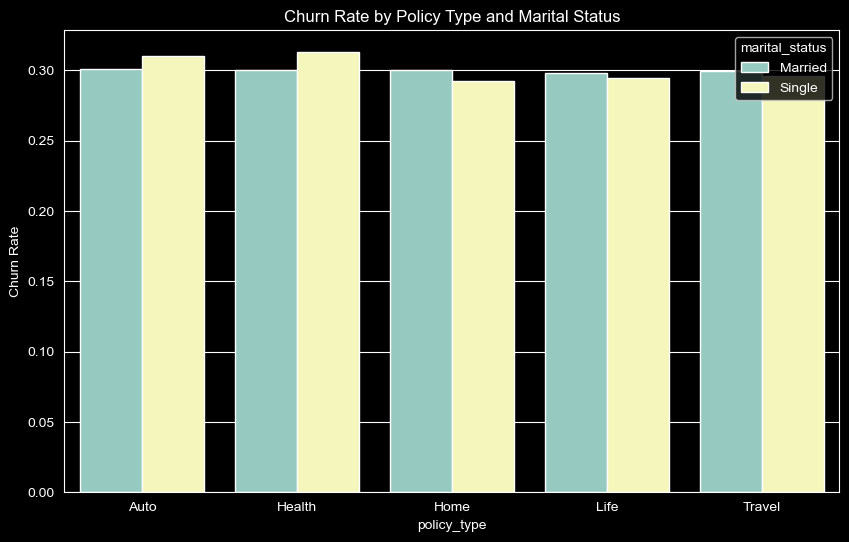

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=policy_churn, x='policy_type', y='rate', hue='marital_status')

plt.title('Churn Rate by Policy Type and Marital Status')
plt.ylabel('Churn Rate')
plt.show()

### 건강보험의 경우 결혼을 한 경우 이탈율이 낮았으나, 집 보험이나 생명보험은 결혼을 한 경우 이탈률이 높았고, 전반적으로 유의미한 차이가 있다 보기 어려움.

In [11]:
# 4. 보험타입/ 결혼여부/ 연령대별 이탈률 비교
policy_age_churn = df.groupby(['marital_status','policy_type', 'age_band'])['is_churn'].agg(
    churn_num='sum',
    total_num='count',
    rate='mean'
).reset_index()
policy_age_churn

,marital_status,policy_type,age_band,churn_num,total_num,rate
0,Married,Auto,18-24,329,958,0.343424
1,Married,Auto,25-34,399,1326,0.300905
2,Married,Auto,35-44,332,1264,0.262658
3,Married,Auto,45-54,335,1338,0.250374
4,Married,Auto,55-64,381,1266,0.300948
...,...,...,...,...,...,...
65,Single,Travel,35-44,55,206,0.266990
66,Single,Travel,45-54,51,192,0.265625
67,Single,Travel,55-64,46,180,0.255556
68,Single,Travel,65-74,71,199,0.356784


In [17]:
g = sns.catplot(
    data=policy_age_churn,
    x='marital_status',
    y='rate',
    hue='policy_type',
    col='age_band',  # 결혼 여부별로 그래프 면(column)을 나눔
    kind='bar',
    height=50,
    # aspect=1.2
)

g.set_axis_labels("Age Band", "Churn Rate (%)")
g.set_titles("{col_name} Group") # 상단 타이틀 설정
g.add_legend(title="Policy Type")

plt.show()

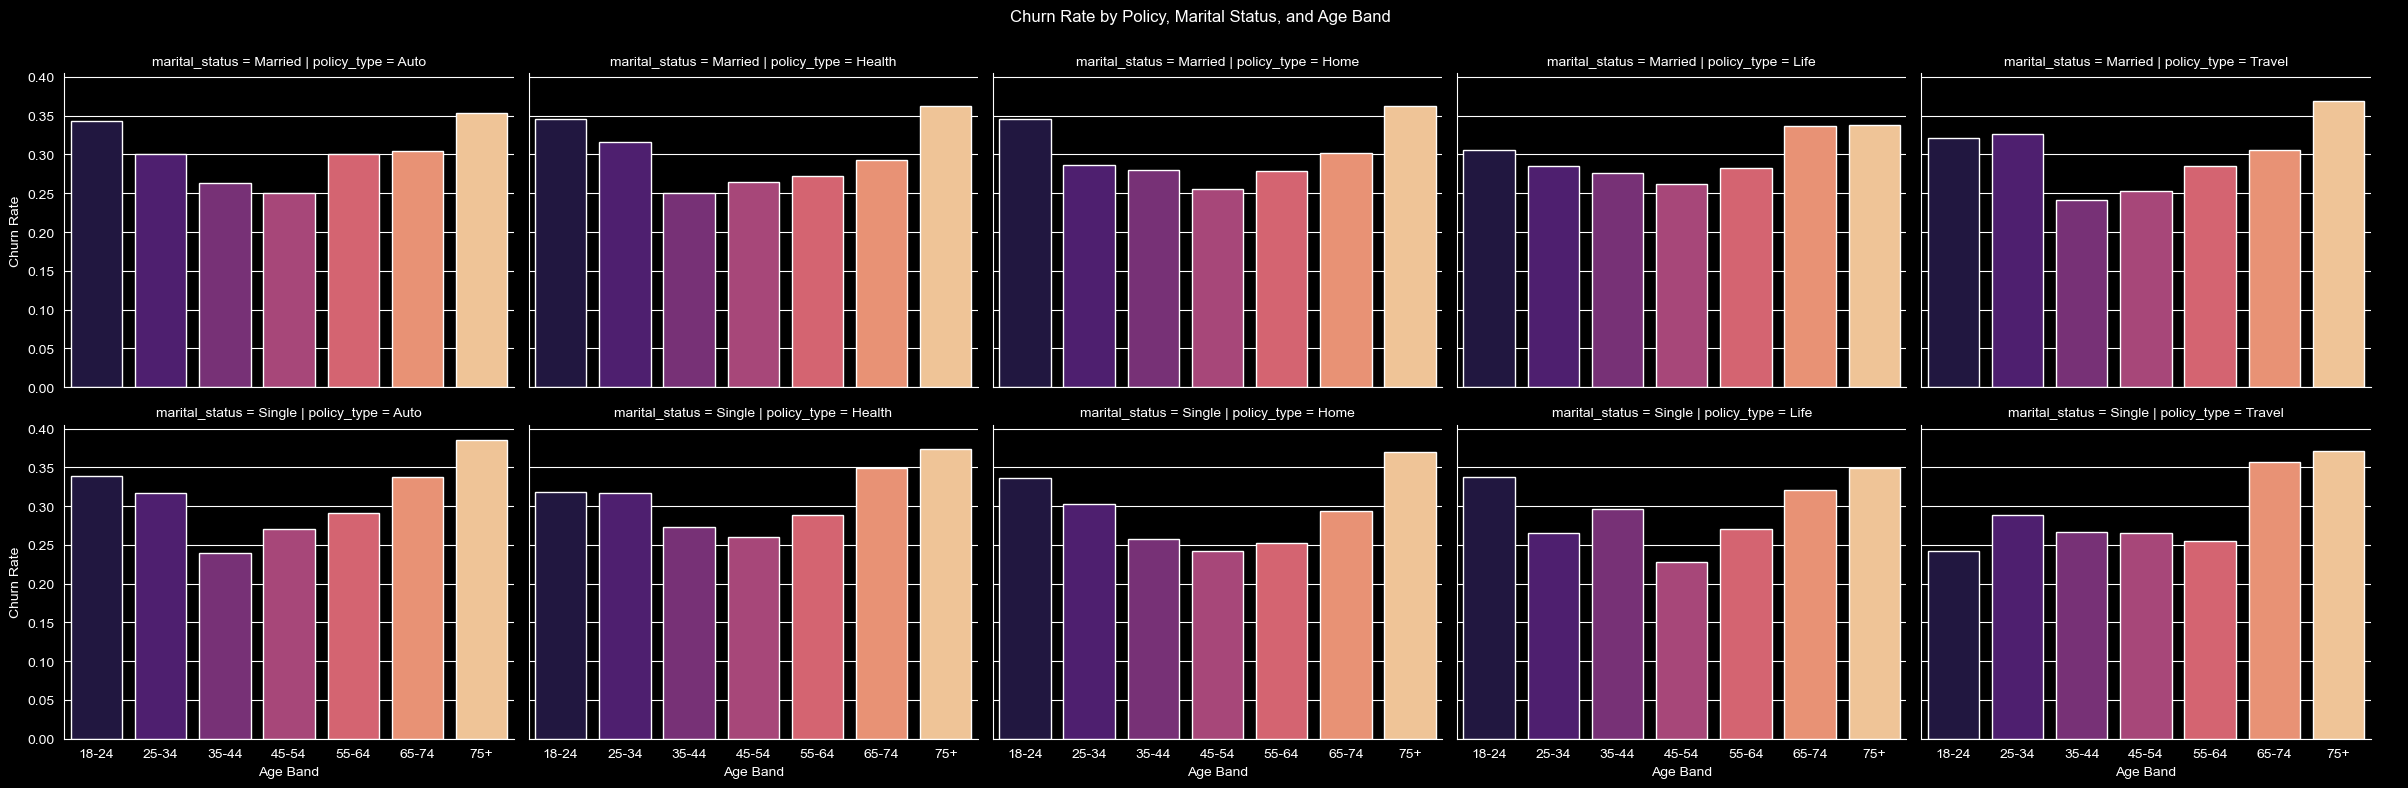

In [18]:
# 3번 데이터를 활용한 FacetGrid 시각화
g = sns.FacetGrid(policy_age_churn, col="policy_type", row="marital_status", height=4, aspect=1.2)
g.map_dataframe(sns.barplot, x="age_band", y="rate", palette="magma", hue="age_band")

# 레이아웃 및 타이틀 조정
g.set_axis_labels("Age Band", "Churn Rate")
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Churn Rate by Policy, Marital Status, and Age Band')
plt.show()